# Rapid Adiabatic Passage Simulation

This notebook demonstrates the `rap_simulation` package for simulating rapid adiabatic passage (RAP) in Rubidium-87 atoms using QuTiP.

## Contents
1. Basic Simulation
2. Visualizing Results
3. Bloch Sphere Animation
4. Adiabaticity Analysis
5. Parameter Sweeps
6. Comparing Pulse Shapes


In [2]:
# Add parent directory to path for development
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

# Import from our package
from rap_simulation import (
    Rubidium87,
    RapidAdiabaticPassage,
    SimulationParams,
    adiabaticity_criterion,
)
from rap_simulation.visualization import (
    plot_probabilities,
    plot_pulse_and_detuning,
    plot_expectation_values,
    plot_adiabaticity,
    plot_combined,
    plot_bloch_trajectory,
    animate_bloch,
)
from rap_simulation.scans import sweep_time_scan, frequency_span_scan
from rap_simulation.pulses import list_pulses
from rap_simulation.detuning import list_detunings

# For inline animations
from matplotlib import rc
rc('animation', html='jshtml')

%matplotlib inline


## 1. Basic Simulation

Let's set up a simple RAP simulation for Rb-87 atoms.


In [3]:
# Create the atom
atom = Rubidium87()
print(f"Atom: {atom.name}")
print(f"Clock transition frequency: {atom.transition_frequency/1e9:.6f} GHz")


Atom: Rb-87 (clock)
Clock transition frequency: 6.834683 GHz


In [28]:
# Create simulation parameters using the convenience method
params = SimulationParams.for_rb87_clock(
    T=0.4e-3,              # 10 ms total time
    dt=1e-6,             # 1 µs time step
    rabi_freq_hz=10000,  # 10 kHz Rabi frequency
    freq_span_hz=10000,  # 10 kHz frequency span
    sweep_time=0.1e-3,   # 5 ms half-sweep time
)

print(f"Total time: {params.T*1e3:.1f} ms")
print(f"Sweep time: {params.sweep_time*1e3:.2f} ms")
print(f"Rabi frequency: {params.omega/(2*np.pi)/1e3:.1f} kHz")


Total time: 0.4 ms
Sweep time: 0.10 ms
Rabi frequency: 10.0 kHz


In [29]:
# List available pulse shapes and detuning profiles
print("Available pulse shapes:", list_pulses())
print("Available detuning profiles:", list_detunings())


Available pulse shapes: ['constant', 'gaussian', 'lorentzian', 'hyper_secant']
Available detuning profiles: ['linear', 'tanh', 'quadratic']


In [30]:
# Run the simulation
rap = RapidAdiabaticPassage(atom, params)
result = rap.run(pulse="hyper_secant", detuning="linear")

print(f"\nSimulation complete!")
print(f"Final transfer probability: {result.final_p1:.4f}")
print(f"Maximum P1 achieved: {result.max_p1:.4f}")



Simulation complete!
Final transfer probability: 0.9844
Maximum P1 achieved: 0.9875


## 2. Visualizing Results


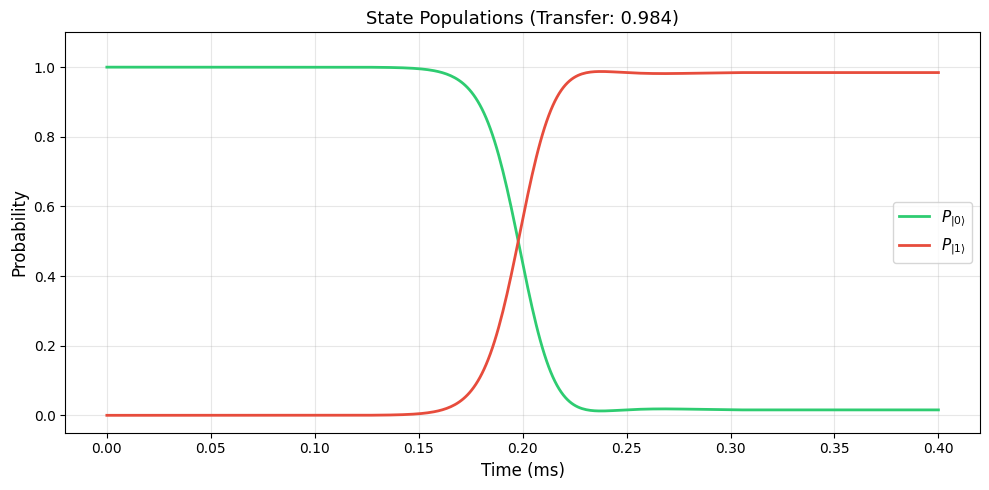

In [31]:
# Plot state probabilities
fig = plot_probabilities(result, time_unit="ms")


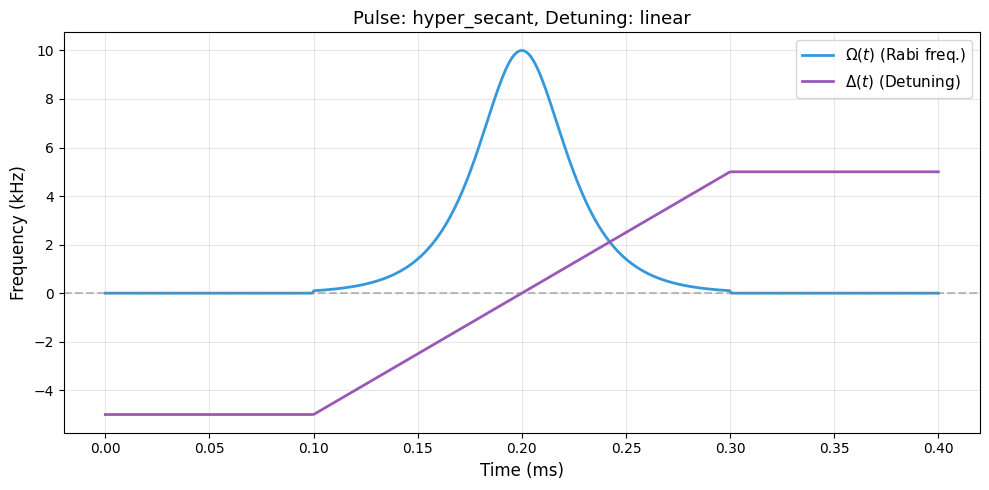

In [32]:
# Plot pulse shape and detuning
fig = plot_pulse_and_detuning(result, time_unit="ms", freq_unit="kHz")


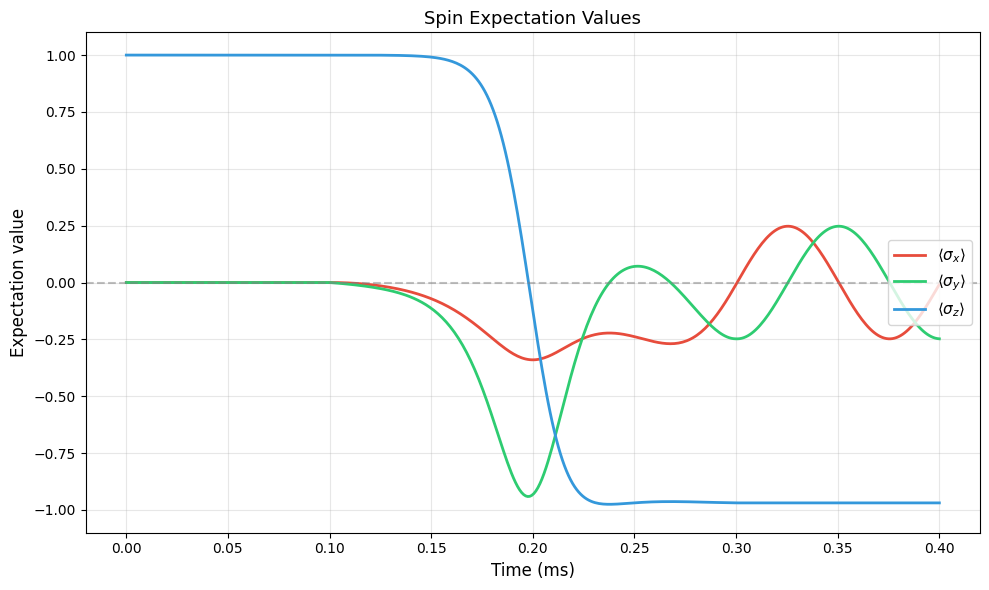

In [33]:
# Plot expectation values using QuTiP's expect()
fig = plot_expectation_values(result, time_unit="ms")


## 3. Bloch Sphere Visualization

Using QuTiP's built-in Bloch class for visualization.


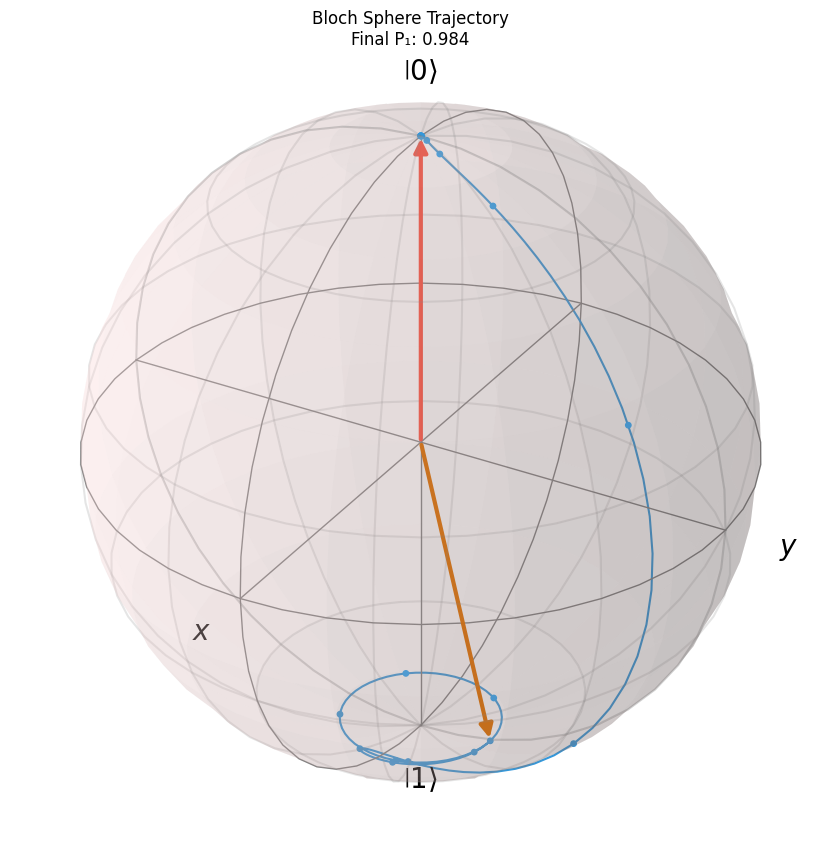

In [34]:
# Static Bloch sphere trajectory
fig, bloch = plot_bloch_trajectory(result)


In [24]:
# Animated Bloch sphere (uncomment to run - may take a moment)
# ani = animate_bloch(result, fps=20, duration=3.0)


## 4. Adiabaticity Analysis

The adiabatic condition requires that the rate of change of the driving field direction is much slower than the effective Rabi frequency.


In [25]:
# Calculate adiabaticity criterion
analysis = adiabaticity_criterion(
    params,
    pulse_name="hyper_secant",
    detuning_name="linear",
)

print(f"Is adiabatic: {analysis.is_adiabatic}")
print(f"Max criterion value: {analysis.max_criterion:.4f}")
print(f"Mean criterion value: {analysis.mean_criterion:.6f}")


Is adiabatic: True
Max criterion value: 0.0171
Mean criterion value: 0.003549


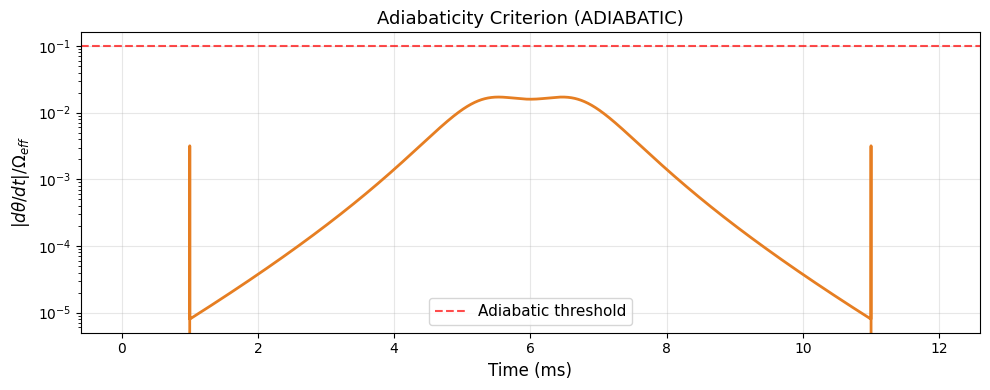

In [26]:
# Plot adiabaticity criterion
fig = plot_adiabaticity(analysis, time_unit="ms")


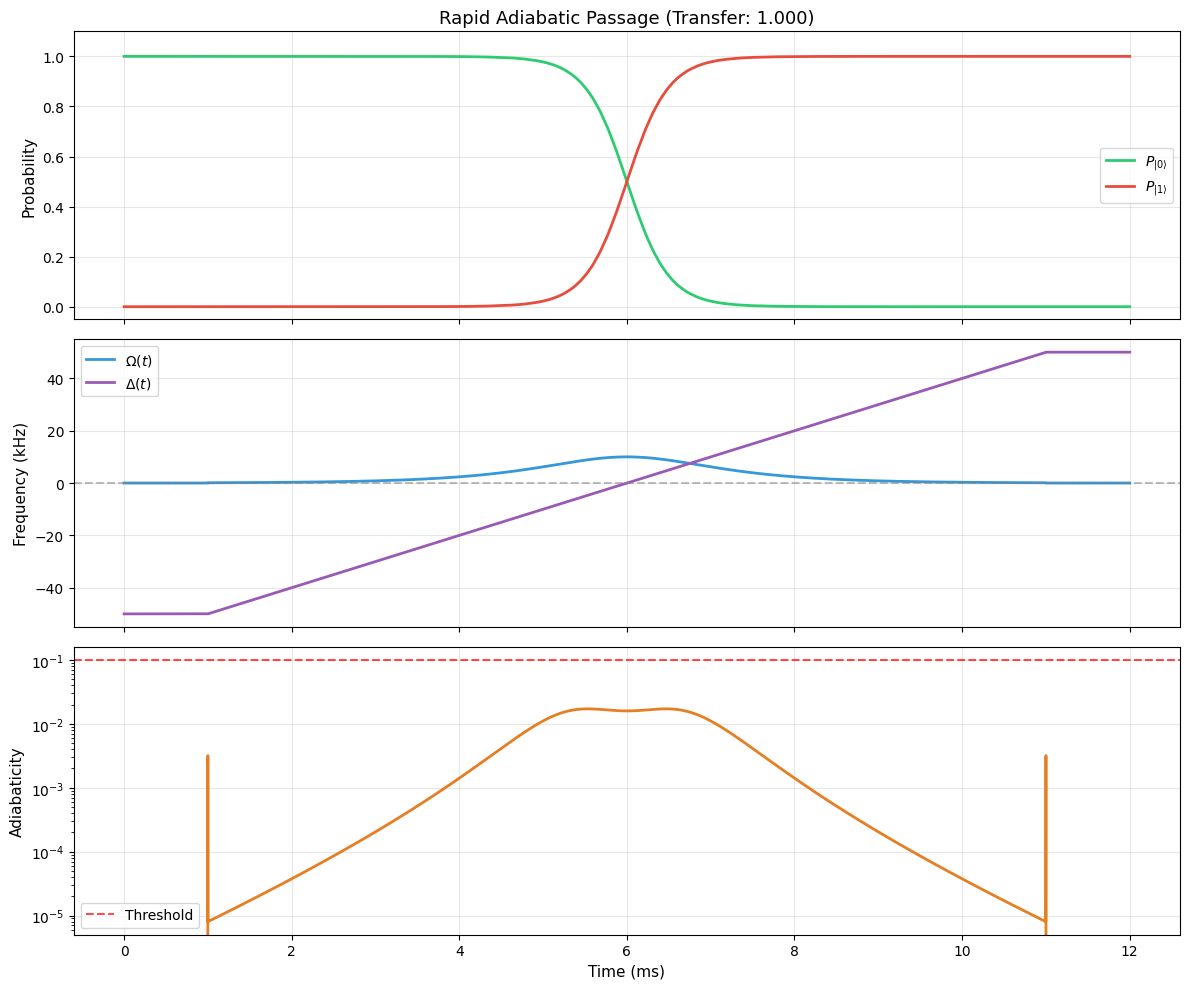

In [27]:
# Combined plot with all information
fig = plot_combined(result, analysis, time_unit="ms")


## 5. Parameter Sweeps

Let's scan the sweep time to find optimal parameters.


In [26]:
# Sweep time scan
sweep_result = sweep_time_scan(
    atom=atom,
    base_params=params,
    t_start=0.001e-3,  # 0.1 ms
    t_end=1.0e-3,    # 1.0 ms
    n_points=300,
    pulse="hyper_secant",
    detuning="linear",
    constant_freq_span=10000,  # Keep 40 kHz span constant
)

print(f"\nOptimal sweep time: {sweep_result.optimal_value*1e3:.3f} ms")
print(f"Maximum P1: {sweep_result.optimal_p1:.4f}")


Sweep time scan: 100%|██████████| 300/300 [00:47<00:00,  6.38it/s]


Optimal sweep time: 0.903 ms
Maximum P1: 1.0000


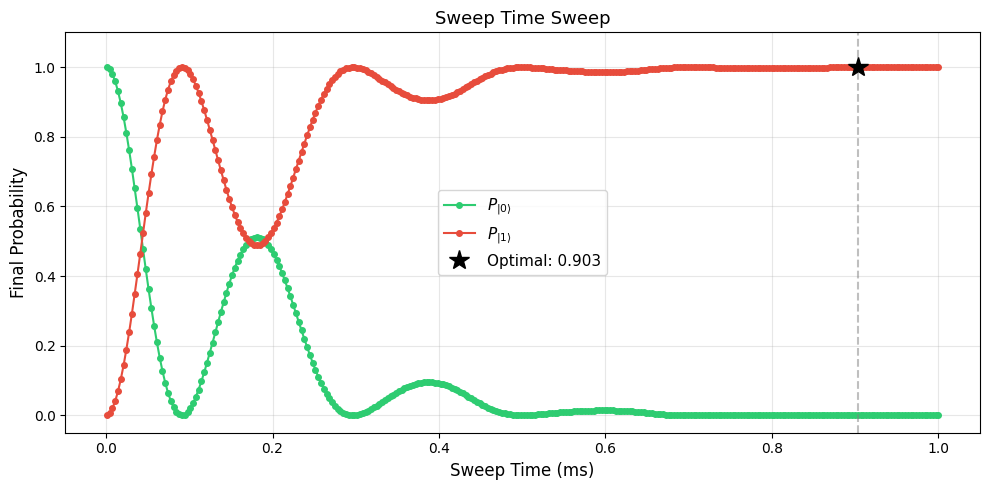

In [27]:
# Plot sweep results
from rap_simulation.visualization.plots import plot_sweep_results

fig = plot_sweep_results(
    sweep_result.parameter_values * 1e3,  # Convert to ms
    sweep_result.p0_final,
    sweep_result.p1_final,
    parameter_name="Sweep Time",
    parameter_unit="ms",
)


Frequency span scan: 100%|██████████| 300/300 [00:02<00:00, 140.26it/s]



Optimal span: 9.699 kHz
Maximum P1: 1.0000


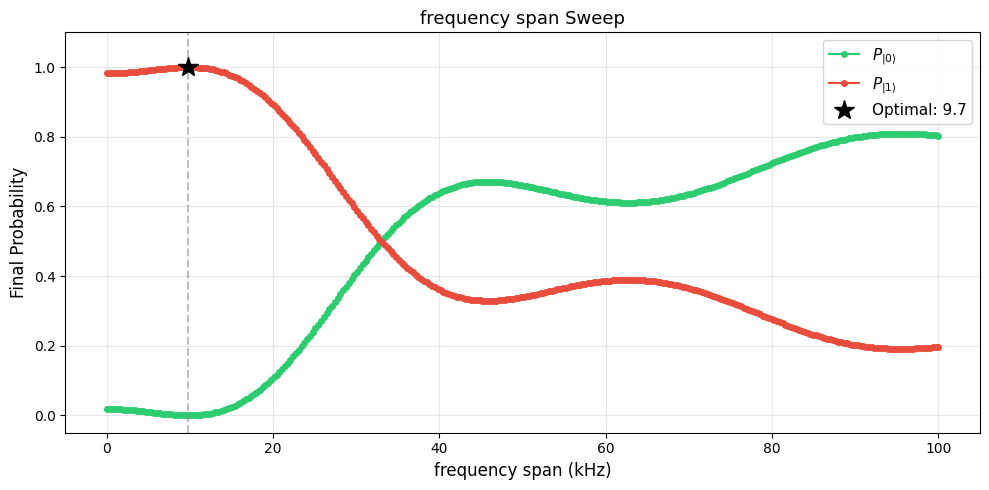

In [50]:
params.sweep_time = 1e-3
params.omega = 10e3
sweep_result = frequency_span_scan(
    atom=atom,
    base_params=params,
    f_start=0,  # 10 kHz
    f_end=100000,   # 100 kHz
    n_points=300,
    pulse="hyper_secant",
    detuning="linear",
)

print(f"\nOptimal span: {sweep_result.optimal_value*1e-3:.3f} kHz")
print(f"Maximum P1: {sweep_result.optimal_p1:.4f}")

fig = plot_sweep_results(
    sweep_result.parameter_values * 1e-3,  # Convert to ms
    sweep_result.p0_final,
    sweep_result.p1_final,
    parameter_name="frequency span",
    parameter_unit="kHz",
)

Spectroscopy scan: 100%|██████████| 300/300 [00:01<00:00, 166.17it/s]


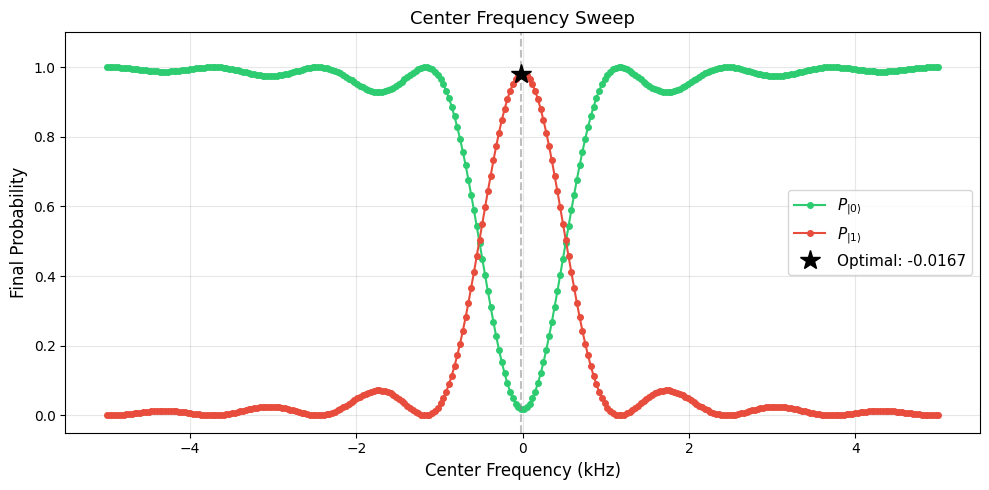

In [53]:
from rap_simulation.scans import spectroscopy_scan
params.sweep_time = 1e-3
params.omega = 10000
params.delta_span = 10000
spectroscopy_result = spectroscopy_scan(
    atom=atom,
    base_params=params,
    center_start=-5e3,
    center_end=5e3,
    n_points=300,
)

fig = plot_sweep_results(
    spectroscopy_result.parameter_values * 1e-3,  # Convert to kHz
    spectroscopy_result.p0_final,
    spectroscopy_result.p1_final,
    parameter_name="Center Frequency",
    parameter_unit="kHz",
)


## 6. Comparing Pulse Shapes

Let's compare different pulse shapes for the same parameters.


In [15]:
from rap_simulation.scans import compare_pulse_shapes

# Compare all pulse shapes
comparison = compare_pulse_shapes(atom, params)

print("Transfer efficiency by pulse shape:")
for pulse_name, p1 in sorted(comparison.items(), key=lambda x: -x[1]):
    print(f"  {pulse_name}: {p1:.4f}")


Transfer efficiency by pulse shape:
  gaussian: 1.0000
  lorentzian: 1.0000
  hyper_secant: 0.9999
  constant: 0.6387


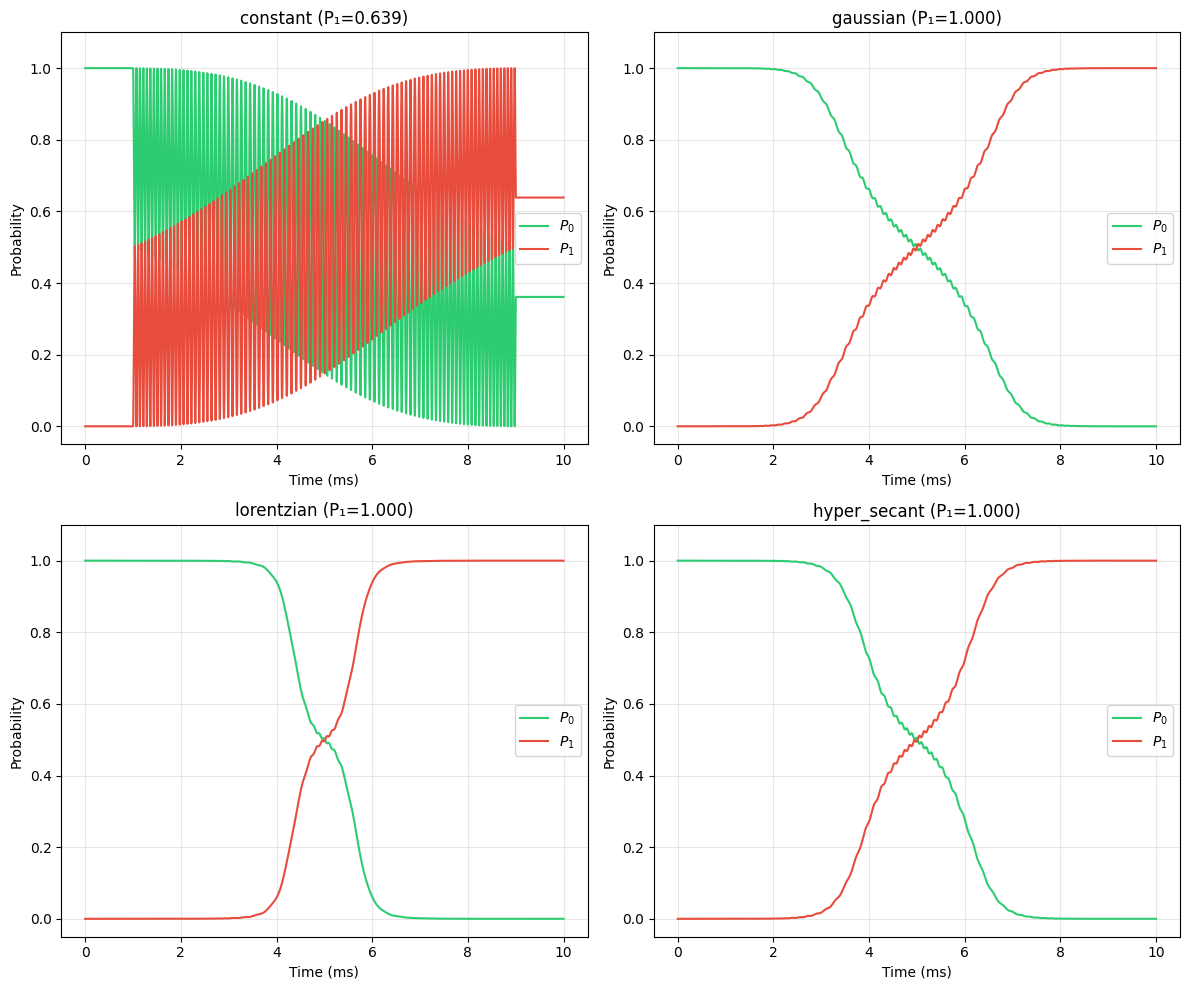

In [16]:
# Visual comparison of all pulse shapes
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, pulse_name in zip(axes.flat, list_pulses()):
    result = rap.run(pulse=pulse_name, detuning="linear")
    times = result.times * 1e3
    
    ax.plot(times, result.p0, label=r'$P_0$', color='#2ecc71')
    ax.plot(times, result.p1, label=r'$P_1$', color='#e74c3c')
    ax.set_title(f'{pulse_name} (P₁={result.final_p1:.3f})')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Probability')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()


## Summary

This package provides:

- **Atom classes**: `Rubidium87` with support for all hyperfine transitions (clock, σ+, σ-, π)
- **Hyperfine transitions**: Pre-defined and custom transitions with Zeeman shift calculations
- **Pulse shapes**: Constant, Gaussian, Lorentzian, Hyperbolic secant (extensible via registry)
- **Detuning profiles**: Linear, Tanh, Quadratic (extensible via registry)
- **Simulation**: `RapidAdiabaticPassage` class using QuTiP's `sesolve`
- **Analysis**: Adiabaticity criteria, Bloch trajectory analysis
- **Visualization**: Probability plots, Bloch sphere (using QuTiP), animations
- **Parameter sweeps**: Sweep time, frequency span, spectroscopy scans


## 7. Different Hyperfine Transitions

The package supports all hyperfine transitions in Rb-87, not just the clock transition. Let's explore magnetic-field-sensitive transitions.


In [19]:
# List all pre-defined transitions
print("Available pre-defined transitions:")
for trans in Rubidium87.list_transitions():
    print(f"  {trans}")


Available pre-defined transitions:
  clock: |F=1, mF=0⟩ → |F=2, mF=0⟩
  σ+ (F=1→2): |F=1, mF=1⟩ → |F=2, mF=2⟩
  σ+ (F=2→1): |F=2, mF=2⟩ → |F=1, mF=1⟩
  σ- (F=1→2): |F=1, mF=-1⟩ → |F=2, mF=-2⟩
  σ- (F=2→1): |F=2, mF=-2⟩ → |F=1, mF=-1⟩


In [20]:
# Compare clock transition vs σ+ transition |F=2, mF=2⟩ → |F=1, mF=1⟩
B_field = 1e-4  # 1 Gauss in Tesla

# Clock transition (field-insensitive)
atom_clock = Rubidium87(B_field=B_field)
print(f"Clock transition: {atom_clock.transition}")
print(f"  Frequency: {atom_clock.transition_frequency/1e9:.9f} GHz")
print(f"  Zeeman sensitivity: {atom_clock.zeeman_sensitivity():.0f} Hz/T (first-order insensitive)")

# σ+ transition (field-sensitive)
atom_sigma = Rubidium87(B_field=B_field, transition=Rubidium87.SIGMA_PLUS_2)
print(f"\nσ+ transition: {atom_sigma.transition}")
print(f"  Frequency: {atom_sigma.transition_frequency/1e9:.9f} GHz")
print(f"  Zeeman sensitivity: {atom_sigma.zeeman_sensitivity()/1e6:.2f} MHz/T")


Clock transition: clock: |F=1, mF=0⟩ → |F=2, mF=0⟩
  Frequency: 6.834683186 GHz
  Zeeman sensitivity: 0 Hz/T (first-order insensitive)

σ+ transition: σ+ (F=2→1): |F=2, mF=2⟩ → |F=1, mF=1⟩
  Frequency: 6.832583174 GHz
  Zeeman sensitivity: -20994.37 MHz/T


In [21]:
# Create a custom transition: |F=2, mF=1⟩ → |F=1, mF=0⟩ (π transition)
custom_trans = Rubidium87.custom_transition(
    F_initial=2, mF_initial=1,
    F_final=1, mF_final=0,
    name="π (2,1→1,0)"
)
atom_custom = Rubidium87(B_field=B_field, transition=custom_trans)
print(f"Custom transition: {atom_custom.transition}")
print(f"  Zeeman sensitivity: {atom_custom.zeeman_sensitivity()/1e6:.2f} MHz/T")


Custom transition: π (2,1→1,0): |F=2, mF=1⟩ → |F=1, mF=0⟩
  Zeeman sensitivity: -6998.12 MHz/T


In [22]:
# Run RAP simulation for the σ+ transition
params_sigma = SimulationParams.for_rb87_clock(
    T=1e-3,
    rabi_freq_hz=10000,
    freq_span_hz=40000,
    sweep_time=0.5e-3,
)

rap_sigma = RapidAdiabaticPassage(atom_sigma, params_sigma)
result_sigma = rap_sigma.run(pulse="hyper_secant", detuning="linear")

print(f"σ+ transition RAP:")
print(f"  Transfer efficiency: {result_sigma.final_p1:.4f}")


σ+ transition RAP:
  Transfer efficiency: 1.0000


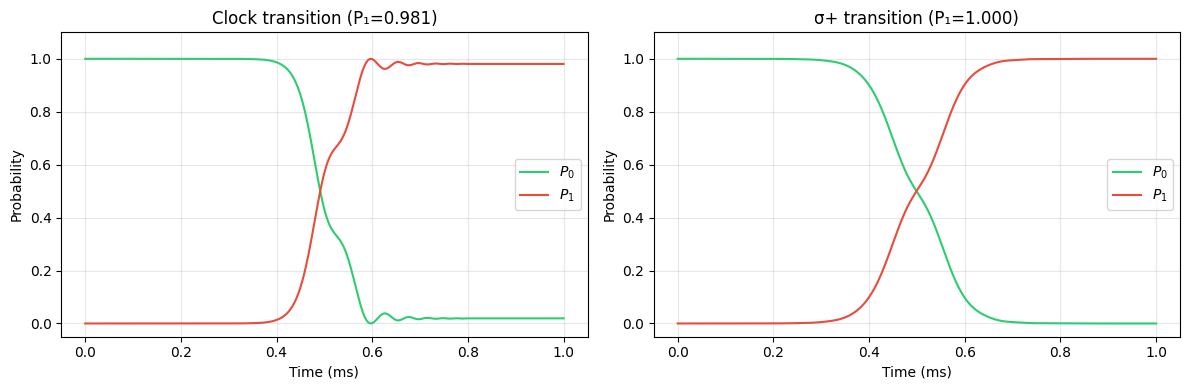

In [23]:
# Compare RAP for clock vs σ+ transition
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Clock transition
axes[0].plot(result.times * 1e3, result.p0, label=r'$P_0$', color='#2ecc71')
axes[0].plot(result.times * 1e3, result.p1, label=r'$P_1$', color='#e74c3c')
axes[0].set_title(f'Clock transition (P₁={result.final_p1:.3f})')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Probability')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.05, 1.1)

# σ+ transition
axes[1].plot(result_sigma.times * 1e3, result_sigma.p0, label=r'$P_0$', color='#2ecc71')
axes[1].plot(result_sigma.times * 1e3, result_sigma.p1, label=r'$P_1$', color='#e74c3c')
axes[1].set_title(f'σ+ transition (P₁={result_sigma.final_p1:.3f})')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Probability')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()


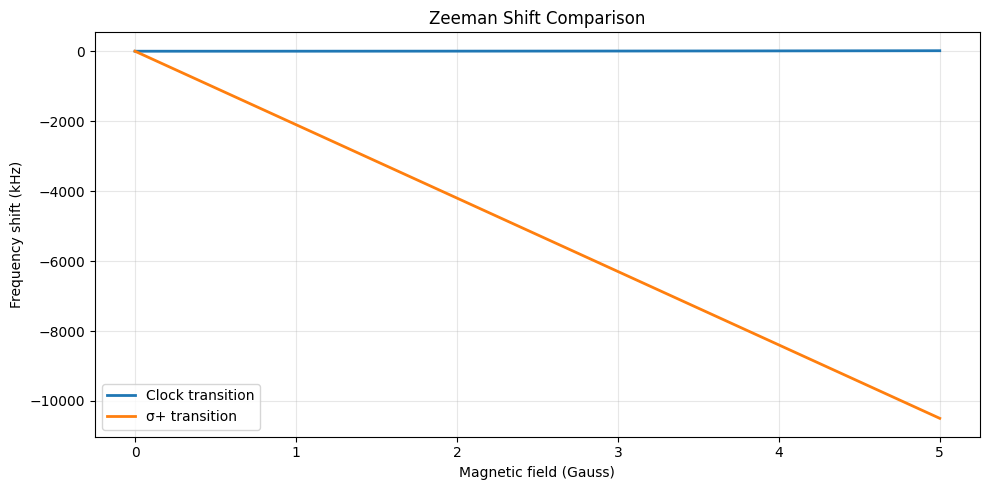

In [24]:
# Show how transition frequency changes with magnetic field
B_fields = np.linspace(0, 5e-4, 50)  # 0 to 5 Gauss

freq_clock = [Rubidium87(B).get_transition_frequency(Rubidium87.CLOCK_TRANSITION, B) 
              for B in B_fields]
freq_sigma = [Rubidium87(B).get_transition_frequency(Rubidium87.SIGMA_PLUS_2, B) 
              for B in B_fields]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(B_fields * 1e4, (np.array(freq_clock) - freq_clock[0]) / 1e3, 
        label='Clock transition', linewidth=2)
ax.plot(B_fields * 1e4, (np.array(freq_sigma) - freq_sigma[0]) / 1e3, 
        label='σ+ transition', linewidth=2)
ax.set_xlabel('Magnetic field (Gauss)')
ax.set_ylabel('Frequency shift (kHz)')
ax.set_title('Zeeman Shift Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
